# 02 - Modelling and results

Run the full pipeline (benchmarks, SARIMAX, feature-based models, Bayesian, and the neural model if TensorFlow is installed), then look at the comparison table and the forecasts. This mirrors `scripts/run_pipeline.py` but keeps the results in memory for inspection.

In [ ]:

%matplotlib inline
import sys
from pathlib import Path
for cand in [Path.cwd(), *Path.cwd().parents]:
    if (cand / 'src' / 'electricity_demand').exists():
        sys.path.insert(0, str(cand / 'src')); break
import warnings; warnings.filterwarnings('ignore')

In [2]:
import matplotlib.pyplot as plt
from electricity_demand import run_pipeline, plotting as viz

In [3]:
# Runs everything end to end and writes to outputs/. Set with_neural=False to
# skip the LSTM, or --no-neural on the command line.
result = run_pipeline(save=True, with_bayesian=True, with_neural=None)
result['metrics']

  weekly points: 301 | hourly gaps filled: 0
Building features ...
Fitting benchmarks ...
Fitting SARIMAX ...


d:\electricity-demand-forecasting\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fitting feature-based models ...
Fitting Bayesian regression ...
Evaluating ...
Saved forecasts, metrics and figures under D:\electricity-demand-forecasting\outputs


,MAE,RMSE,MASE,Bias,vs_snaive_%
model,,,,,
linear_regression,1.262,1.733,0.943,0.758,-42.366
bayesian,1.361,1.883,1.017,0.995,-37.363
hist_gradient_boosting,1.772,2.399,1.324,1.200,-20.215
gradient_boosting,1.937,2.522,1.448,1.166,-16.128
random_forest,1.904,2.540,1.423,1.030,-15.514
feature_model,1.904,2.540,1.423,1.030,-15.514
seasonal_naive,2.319,3.007,1.732,1.732,0.000
sarimax,3.018,3.792,2.255,2.934,26.119
mean,3.789,4.397,2.831,0.481,46.247


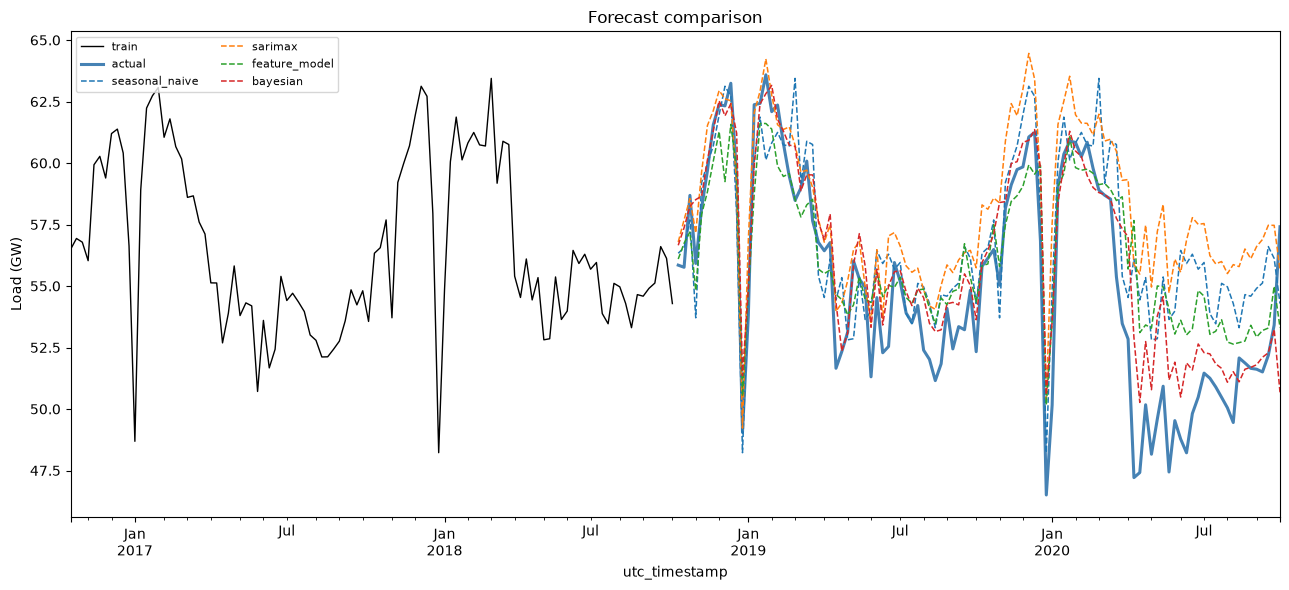

In [4]:
# Forecast comparison: the headline models against the actual two years.
fc_cols = ['seasonal_naive', 'sarimax', 'feature_model', 'bayesian', 'neural']
forecasts = {c: result['forecasts'][c] for c in fc_cols
             if c in result['forecasts'] and result['forecasts'][c].notna().any()}
viz.forecast_comparison(result['train'], result['test'], forecasts); plt.show()

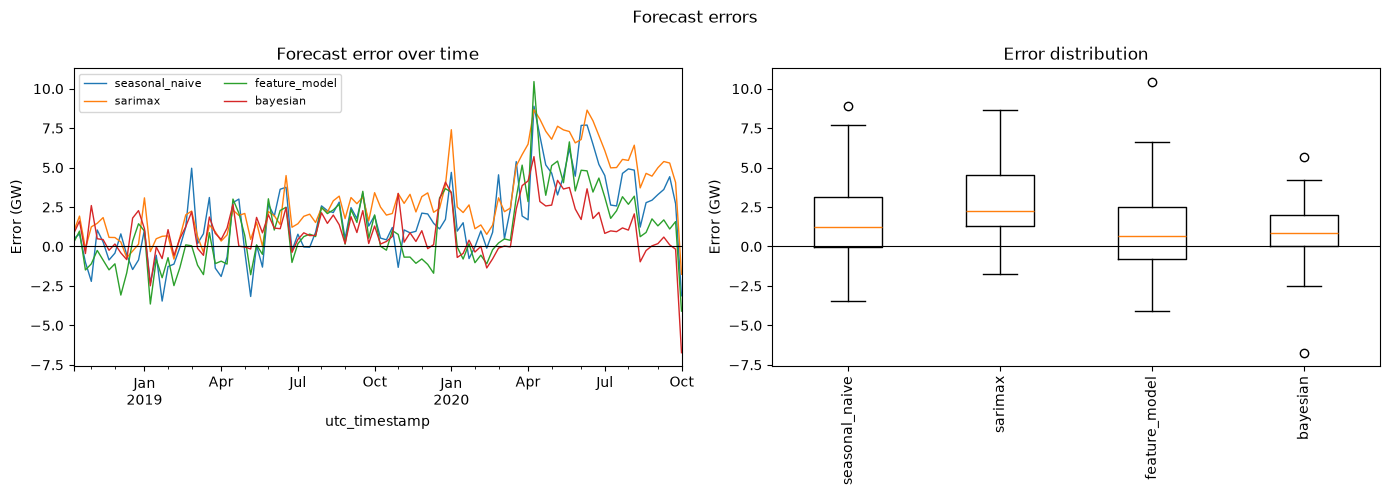

In [5]:
# Error diagnostics: error over time and its spread per model.
viz.error_diagnostics(result['test'], forecasts); plt.show()

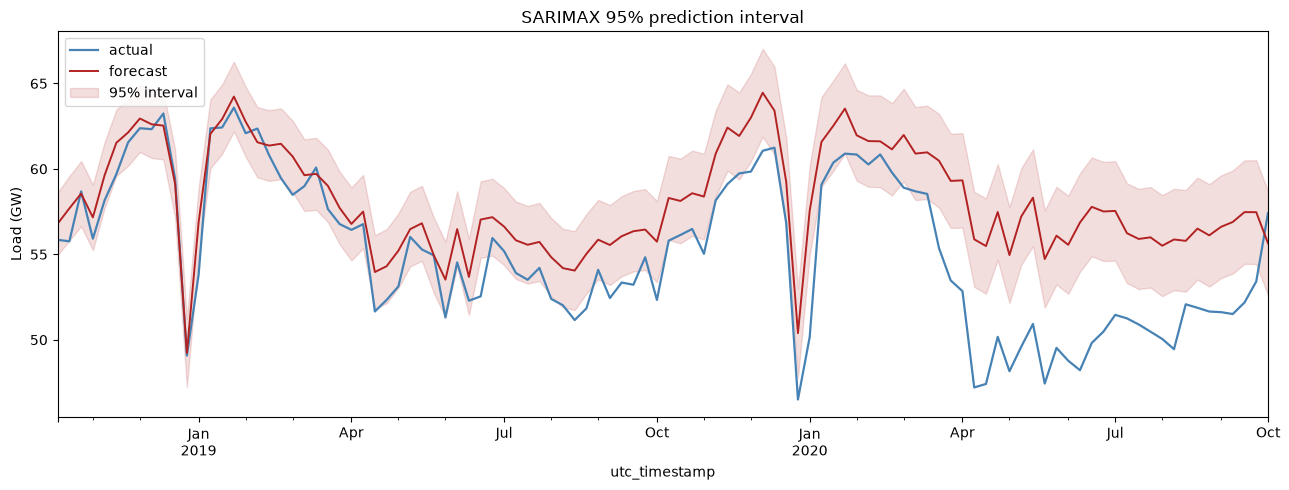

In [6]:
# SARIMAX prediction interval.
lo, hi = result['intervals']['sarimax']
viz.prediction_intervals(result['test'], result['forecasts']['sarimax'], lo, hi,
                         title='SARIMAX 95% prediction interval'); plt.show()

The saved copies of every figure, the forecast table (`outputs/forecasts/all_forecasts.csv`) and the metrics (`outputs/metrics/model_comparison.csv`) are written by the run above.